In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = {
    'StudentID': [1,2,3,4,5,6,7,8,9,10],
    'Name': ['Alice','Bob','Charlie','David','Eva','Frank','Grace','Hannah','Ian','Jane'],
    'Age': [15,16,15,16,15,np.nan,17,16,100,15],  # 100 is an outlier, np.nan is missing
    'Gender': ['F','M','M','M','F','M','F','F','M','F'],
    'MathScore': [85, 90, 78, 92, 88, 75, 95, 89, 200, 85], # 200 is an outlier
    'EnglishScore': [78, 85, np.nan, 80, 82, 77, 90, 84, 70, 88], # missing value
    'ScienceScore': [92, 88, 85, 95, 90, 78, 93, 87, 89, np.nan] # missing value
}

df = pd.DataFrame(data)
print(df)

   StudentID     Name    Age Gender  MathScore  EnglishScore  ScienceScore
0          1    Alice   15.0      F         85          78.0          92.0
1          2      Bob   16.0      M         90          85.0          88.0
2          3  Charlie   15.0      M         78           NaN          85.0
3          4    David   16.0      M         92          80.0          95.0
4          5      Eva   15.0      F         88          82.0          90.0
5          6    Frank    NaN      M         75          77.0          78.0
6          7    Grace   17.0      F         95          90.0          93.0
7          8   Hannah   16.0      F         89          84.0          87.0
8          9      Ian  100.0      M        200          70.0          89.0
9         10     Jane   15.0      F         85          88.0           NaN


In [3]:
# Check missing values
print(df.isnull().sum())

StudentID       0
Name            0
Age             1
Gender          0
MathScore       0
EnglishScore    1
ScienceScore    1
dtype: int64


In [4]:
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['EnglishScore'].fillna(df['EnglishScore'].mean(), inplace=True)
df['ScienceScore'].fillna(df['ScienceScore'].mean(), inplace=True)

In [5]:
# Age should be between 10 and 20
df['Age'] = df['Age'].apply(lambda x: np.nan if x < 10 or x > 20 else x)
df['Age'].fillna(df['Age'].mean(), inplace=True)

In [6]:
numeric_cols = ['MathScore','EnglishScore','ScienceScore','Age']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"Outliers in {col}:")
    print(outliers[[col]])

Outliers in MathScore:
   MathScore
5         75
8        200
Outliers in EnglishScore:
Empty DataFrame
Columns: [EnglishScore]
Index: []
Outliers in ScienceScore:
   ScienceScore
5          78.0
Outliers in Age:
Empty DataFrame
Columns: [Age]
Index: []


In [7]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    df[col] = np.where(df[col] > upper, upper, df[col])
    df[col] = np.where(df[col] < lower, lower, df[col])

In [8]:
# Check original skewness
print("Skewness before transformation:", df['MathScore'].skew())

# Apply log transformation
df['MathScore_log'] = np.log(df['MathScore'])

# Check skewness after transformation
print("Skewness after log transformation:", df['MathScore_log'].skew())

Skewness before transformation: -0.04595070444785996
Skewness after log transformation: -0.26555200047070904


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


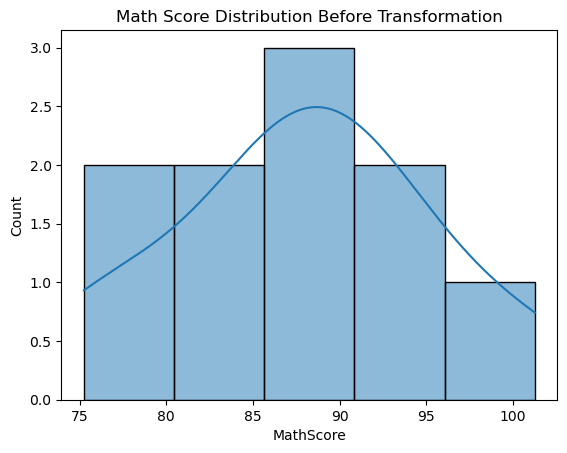

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


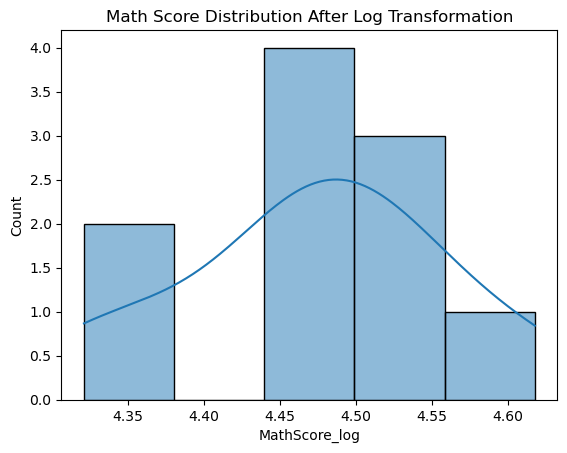

In [9]:
sns.histplot(df['MathScore'], kde=True)
plt.title("Math Score Distribution Before Transformation")
plt.show()

sns.histplot(df['MathScore_log'], kde=True)
plt.title("Math Score Distribution After Log Transformation")
plt.show()

In [10]:
print(df)

   StudentID     Name     Age Gender  MathScore  EnglishScore  ScienceScore  \
0          1    Alice  15.000      F      85.00     78.000000     92.000000   
1          2      Bob  16.000      M      90.00     85.000000     88.000000   
2          3  Charlie  15.000      M      78.00     81.555556     85.000000   
3          4    David  16.000      M      92.00     80.000000     95.000000   
4          5      Eva  15.000      F      88.00     82.000000     90.000000   
5          6    Frank  15.625      M      75.25     77.000000     80.875000   
6          7    Grace  17.000      F      95.00     90.000000     93.000000   
7          8   Hannah  16.000      F      89.00     84.000000     87.000000   
8          9      Ian  15.625      M     101.25     70.000000     89.000000   
9         10     Jane  15.000      F      85.00     88.000000     88.555556   

   MathScore_log  
0       4.442651  
1       4.499810  
2       4.356709  
3       4.521789  
4       4.477337  
5       4.320816